# PIMA INDIANS DIABETES - CLASSIFICATION

## Version 2 - Scaling

### Khai báo thư viện nâng cao
- Sử dụng Pipeline để tránh rò rỉ dữ liệu (data leakage) và SimpleImputer để xử lý giá trị 0.

In [2]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

## 1. Nạp dữ liệu

In [3]:
data_path = os.path.join(os.getcwd(), "..", "data", "pima-indians-diabetes.csv")
col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(data_path, header=None, names=col_names)
print(f"Đã nạp {len(df)} dòng dữ liệu.")
print(f"Shape: {df.shape}")
df.head(10)

Đã nạp 768 dòng dữ liệu.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Chia tập dữ liệu (Split Data)

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

- Tạo ra lớp BasePreprocessor kế thừa từ BaseEstimator và TransformerMixin.

- Mục đích: Tự động hóa việc tìm và thay thế các giá trị 0 vô lý trong các cột y tế (Glucose, BloodPressure...) thành NaN. Việc này giúp bước SimpleImputer phía sau nhận diện đúng đâu là dữ liệu cần điền khuyết.

In [ ]:
class BasePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].replace(0, np.nan)
        return X

## 3. Huấn luyện mô hình Baseline (Logistic Regression)

- Danh sách mô hình: Khởi tạo 4 thuật toán phổ biến:

  - LogisticRegression: Mô hình tuyến tính cơ bản.

  - RandomForestClassifier: Mô hình dựa trên cây quyết định (mạnh mẽ với dữ liệu bảng).

  - SVC: Mô hình Support Vector Machine.

  - KNeighborsClassifier: Mô hình dựa trên khoảng cách.

In [6]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

## 4. Đánh giá chi tiết

- Trục tung (Actual): Giá trị thực tế của bệnh nhân.

- Trục hoành (Predicted): Giá trị mô hình dự đoán.

- Nó giúp nhận diện ngay lập tức mô hình đang đoán sai ở đâu: Nhầm người khỏe thành có bệnh (False Positive) hay bỏ sót người bệnh (False Negative).

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + title)
    plt.tight_layout()
    plt.show()

- Kiểm chéo (Cross Validation): Sử dụng StratifiedKFold chia dữ liệu thành 5 phần để tính điểm cv_f1. Việc này giúp xác định xem mô hình có hoạt động ổn định trên các tập dữ liệu khác nhau hay không.

- Huấn luyện lại (Training): Sau khi kiểm tra độ ổn định, mô hình thực hiện học trên toàn bộ tập X_train để tận dụng tối đa tri thức từ dữ liệu.

- Kiểm tra độc lập (Testing): Dự báo trên tập X_test (dữ liệu mô hình chưa từng thấy) để tính toán Accuracy và F1-score thực tế.

In [78]:
def run_pipeline(name, pipeline):
    # define CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    # train full train set
    pipeline.fit(X_train, y_train)

    # predict test
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "method": name,
        "cv_f1": round(cv_scores.mean(), 4),
        "test_acc": round(acc, 4),
        "test_f1": round(f1, 4)
    }


=== Logistic ===


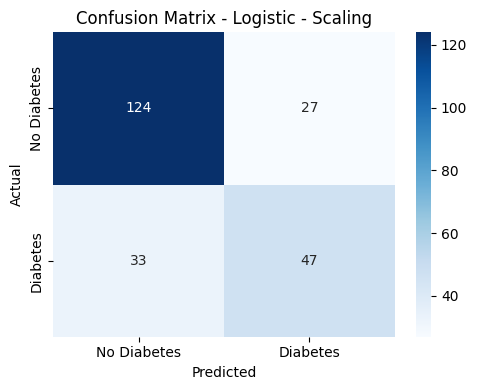


=== RandomForest ===


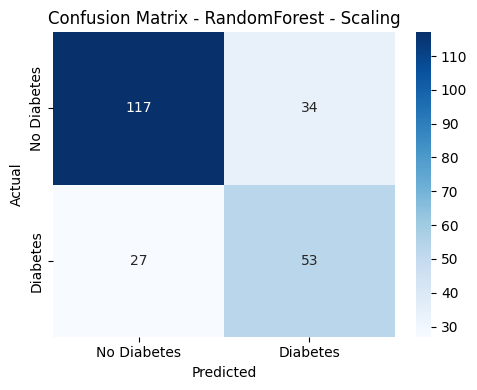


=== SVM ===


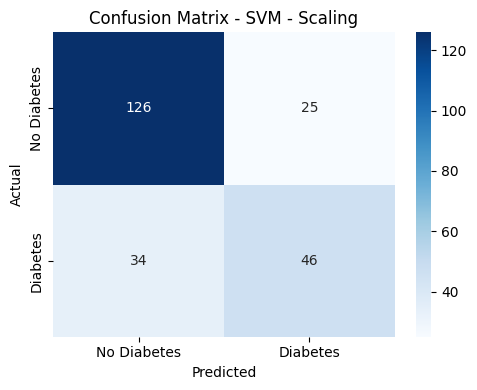


=== KNN ===


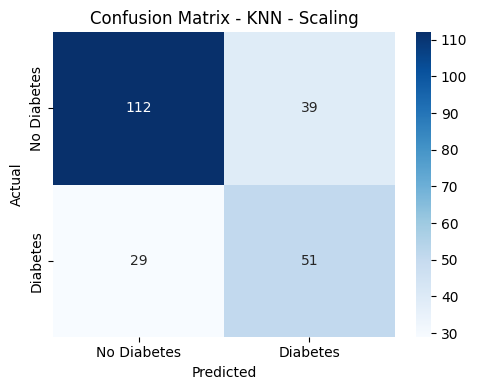

In [79]:
results = []

for model_name, model in models.items():
    print(f"\n=== {model_name} ===")

    # ---------- BASELINE ----------
    steps = [
        ('base', BasePreprocessor()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]

    steps.append(('model', model))

    pipeline = Pipeline(steps)
    results.append(run_pipeline(f"{model_name}_baseline", pipeline))

    plot_confusion_matrix(y_test, pipeline.predict(X_test), f"{model_name} - Scaling")

In [80]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="test_f1", ascending=False)

df_results

,method,cv_f1,test_acc,test_f1
1,RandomForest_baseline,0.6282,0.7359,0.6347
0,Logistic_baseline,0.6356,0.7403,0.6104
2,SVM_baseline,0.6200,0.7446,0.6093
3,KNN_baseline,0.6225,0.7056,0.6000


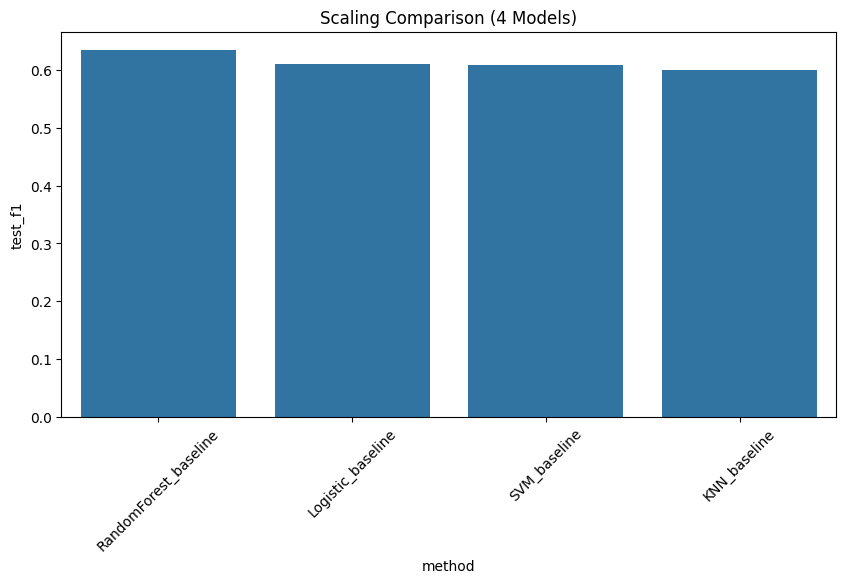

In [81]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="method", y="test_f1")
plt.xticks(rotation=45)
plt.title("Scaling Comparison (4 Models)")
plt.show()

### Tổng kết Version 2:
- Mô hình: Thử nghiệm đa thuật toán (Logistic Regression, Random Forest, SVM, KNN).

- Tiền xử lý: Sử dụng BasePreprocessor tùy chỉnh để chuyển giá trị 0 thành NaN; kết hợp SimpleImputer (median) và StandardScaler trong Pipeline.

- Kết quả: Cải thiện độ chính xác và tính ổn định nhờ xử lý dữ liệu thiếu và chuẩn hóa đặc trưng; tìm ra mô hình tối ưu nhất để chuẩn bị cho bước tinh chỉnh.